# Interpret the Final Average

In this notebook, we take the output final spectrum from the `average-over-days` notebook, and interpret it with the cosmological model.

In [1]:
datadir: str = "/data7/smurray/edges/projects_with_nive/edges-bowman2018-pipeline/output-notebooks/"
avgspec_file: str = "averaged_spectrum.gsh5"

## Imports and Data Loading

In [2]:
from pygsdata import GSData
from edges_cal import modelling as mdl
from edges_estimate.fitting import SemiLinearFit
from edges_estimate.eor_models import AbsorptionProfile
import numpy as np
import matplotlib.pyplot as plt
from edges_pipelines import DATA

In [25]:
plt.style.use("default")

In [26]:
data = GSData.from_file(f"{datadir}/{avgspec_file}")

In [27]:
mask = data.flagged_nsamples[0,0,0]>0

In [28]:
eor_model = AbsorptionProfile(
    params={
        'amp': {'min': 0, 'max': 1.0, 'fiducial': 0.5}, 
        'tau': {'min': 0.1, 'max': 30, 'fiducial': 0.1}, 
        'w': {'min': 3, 'max': 25, 'fiducial': 17.0}, 
        'nu0': {'min': 50, 'max': 100, 'fiducial': 75.0}
    }, 
    freqs=data.freqs.to_value("MHz")[mask]
)

In [29]:
alan = np.genfromtxt("/home/smurray/data4/edges/alans-pipeline/scripts/H2CaseFieldData/final_average_2024-10-02_01-18.txt", usecols=(1, 3, 6, 9, 12), names=('freq', 'tant', 'model', 'resid', 'weight'))

In [30]:
alan2 = np.genfromtxt(
    "/home/smurray/data4/edges/alans-pipeline/results/H2-final-average.csv",
    skip_header=1, names=['freq', 'weight', 'tsky', 'tres1', 'tres2', 'tmodel', 't21'], delimiter=','
)

In [31]:
sf = SemiLinearFit(
    fg=mdl.PhysicalLin(n_terms=5).at(x=data.freqs.to_value("MHz")[mask]), 
    eor=eor_model, 
    spectrum=data.data[0,0,0,mask], 
    sigma=0.3
)

In [32]:
sffit = sf()

In [33]:
sffit.x

array([ 0.5513404 ,  6.70836208, 18.75137373, 78.31899111])

In [34]:
alan = np.genfromtxt("/home/smurray/data4/edges/alans-pipeline/scripts/H2CaseFieldData/final_average_latest.txt",  usecols=(1, 3, 6, 9, 12), names=('freq', 'tant', 'model', 'resid', 'weight'))

In [35]:
orig = np.genfromtxt(DATA / "figure1_plotdata.csv",  delimiter=',', skip_header=1)

In [36]:
sffit.success

True

In [37]:
sfal = SemiLinearFit(
    fg=mdl.PhysicalLin(n_terms=5).at(x=data.freqs.to_value("MHz")[mask]), 
    eor=eor_model, 
    spectrum=alan['tant'][mask], 
    sigma=0.3
)
sfalfit = sfal()

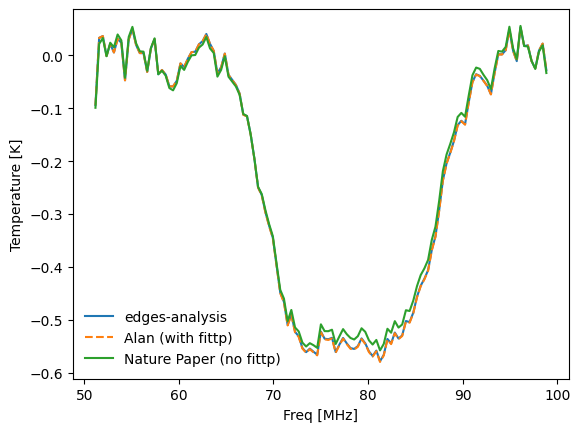

In [38]:
plt.plot(data.freqs[mask], sf.get_eor(sffit.x) + sf.get_resid(sffit.x), label='edges-analysis')
plt.plot(data.freqs[mask], sfal.get_eor(sfalfit.x) + sfal.get_resid(sfalfit.x), label='Alan (with fittp)', ls='--')
plt.plot(data.freqs[mask], orig[mask, -1], label='Nature Paper (no fittp)')
plt.xlabel("Freq [MHz]")
plt.ylabel("Temperature [K]")
plt.legend(frameon=False)